In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Preprocessing and Wrangling

#### 1. Load the dataset using Python Library Pandas

In [2]:
df = pd.read_csv("ecommerce_dataset.csv")
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0,1.0,0.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0,1.0,0.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0,1.0,0.0


In [3]:
df.shape

(506, 14)

#### 2. Check types of data

In [4]:
df.dtypes

order_id                 int64
product                 object
category                object
price                  float64
quantity                 int64
payment_method          object
date                    object
total                  float64
Month                   object
Discount               float64
City Code              float64
Order Priority Code    float64
Latitude               float64
Longtitude             float64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             506 non-null    int64  
 1   product              506 non-null    object 
 2   category             506 non-null    object 
 3   price                506 non-null    float64
 4   quantity             506 non-null    int64  
 5   payment_method       506 non-null    object 
 6   date                 506 non-null    object 
 7   total                506 non-null    float64
 8   Month                506 non-null    object 
 9   Discount             506 non-null    float64
 10  City Code            491 non-null    float64
 11  Order Priority Code  487 non-null    float64
 12  Latitude             506 non-null    float64
 13  Longtitude           506 non-null    float64
dtypes: float64(7), int64(2), object(5)
memory usage: 55.5+ KB


#### 3. Drop irrelevant columns (Latitude, Longtitude)

In [6]:
df = df.drop(['Latitude', 'Longtitude'], axis=1)

In [7]:
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0


#### 4. Rename columns City Code to City & Order Priority Code to Order Priority

In [8]:
df = df.rename(columns={
    'City Code': 'City',
    'Order Priority Code': 'Order Priority'
})

In [9]:
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0


#### 5. Check duplicate rows

In [10]:
duplicated_count = df.duplicated().sum()

In [11]:
duplicated_count

np.int64(6)

#### 6. Drop duplicate records

In [12]:
df = df.drop_duplicates()
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City,Order Priority
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.00,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.10,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.10,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.10,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.00,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Watch,Electronics,66152.43,2,JazzCash,10/05/2024,132304.86,May,0.65,4.0,1.0
496,497,Laptop,Electronics,10745.15,2,Easypaisa,11/05/2024,21490.30,May,0.70,4.0,1.0
497,498,Laptop,Electronics,27141.95,1,JazzCash,12/05/2024,27141.95,May,0.70,4.0,1.0
498,499,Bag,Fashion,59608.91,3,Credit Card,13/05/2024,178826.73,May,0.80,4.0,1.0


#### 7. Check missing and null values

In [13]:
df.isnull().sum()

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64

#### 8. Fill missing sales value by their median

In [14]:
df.isnull().sum()

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64

In [15]:
if df['City'].isnull().sum() > 0:
    mode_city = df['City'].mode()[0]
    df['City'] = df['City'].fillna(mode_city)
    print(f"Filled missing City values with mode: {mode_city}")

if df['Order Priority'].isnull().sum() > 0:
    mode_priority = df['Order Priority'].mode()[0]
    df['Order Priority'] = df['Order Priority'].fillna(mode_priority)
    print(f"Filled missing Order Priority values with mode: {mode_priority}")


print(df.isnull().sum())


Filled missing City values with mode: 2.0
Filled missing Order Priority values with mode: 3.0
order_id          0
product           0
category          0
price             0
quantity          0
payment_method    0
date              0
total             0
Month             0
Discount          0
City              0
Order Priority    0
dtype: int64


##### Create a mapping for City codes to names

In [16]:
city_mapping = {
    1: 'Karachi',
    2: 'Lahore',
    3: 'Islamabad',
    4: 'Faisalabad',
    5: 'Quetta',
    6: 'Peshawar'
}

##### Create a mapping for Order Priority codes to names

In [17]:
priority_mapping = {
    0: 'LOW',
    1: 'MEDIUM',
    2: 'HIGH',
    3: 'CRITICAL'
}

#### 1) Top 5 Best Selling Products

#### a) Write Observation

#### b) (Bar Chart) Using Seaborn

In [18]:
product_sales = df.groupby('product')['total'].sum().sort_values(ascending=False)
product_sales

product
Headphones    9414259.95
Watch         9295181.97
Mobile        8478520.28
Shoes         8304435.17
Laptop        7908062.14
Bag           7799476.91
Name: total, dtype: float64

In [19]:
top_5_products = product_sales.head(5)
top_5_products

product
Headphones    9414259.95
Watch         9295181.97
Mobile        8478520.28
Shoes         8304435.17
Laptop        7908062.14
Name: total, dtype: float64

In [20]:
top_5_products = (top_5_products/1000000).round(2)
top_5_products

product
Headphones    9.41
Watch         9.30
Mobile        8.48
Shoes         8.30
Laptop        7.91
Name: total, dtype: float64

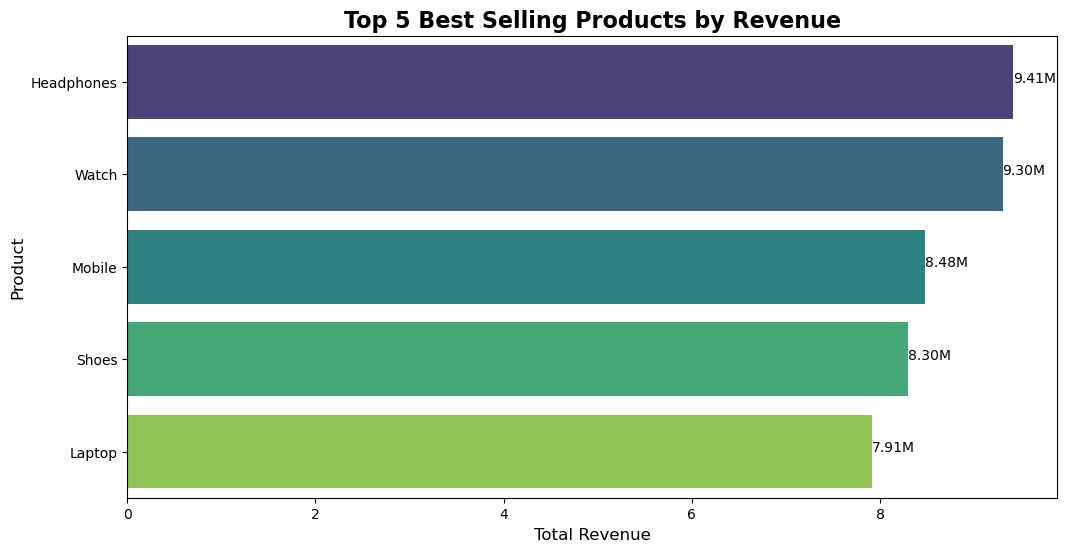

In [21]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_5_products.values, y=top_5_products.index, palette='viridis')
plt.title('Top 5 Best Selling Products by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product', fontsize=12)

for i, v in enumerate(top_5_products):
    ax.text(v , i, f'{v:,.2f}M', fontsize=10)

plt.show()

#### 2) Payment Method Distribution

#### a) Write Observation

#### b) (Pie Chart) Using Matplotlib

Payment Method Distribution:
payment_method
JazzCash       112
Credit Card    107
Easypaisa      105
COD             97
Debit Card      79
Name: count, dtype: int64


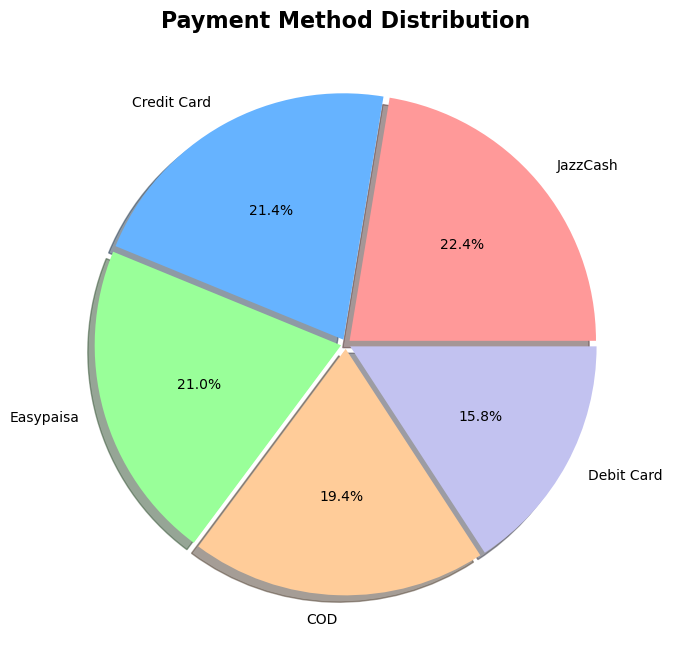

In [39]:
payment_distribution = df['payment_method'].value_counts()
print("Payment Method Distribution:")
print(payment_distribution)

plt.figure(figsize=(8, 8))
plt.pie(payment_distribution.values, labels=payment_distribution.index, 
        autopct='%1.1f%%', colors=colors,
        explode=[0.02]*len(payment_distribution), shadow=True)
plt.title('Payment Method Distribution', fontsize=16, fontweight='bold')
plt.show()

#### 3) Month-wise Sales

#### a) Write Observation

#### b) (Line Chart) Using Matplotlib

In [41]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

In [44]:
monthly_sales = df.groupby('Month')['total'].sum().reindex(month_order)
monthly_sales

Month
January      6238414.59
February     5545040.22
March        6711119.66
April        6275753.74
May          5909845.92
June         2860920.11
July         2688475.62
August       2557288.54
September    2515916.08
October      3139444.82
November     2805153.37
December     3952563.75
Name: total, dtype: float64

In [45]:
monthly_sales = (monthly_sales/1000000).round(2)
monthly_sales

Month
January      6.24
February     5.55
March        6.71
April        6.28
May          5.91
June         2.86
July         2.69
August       2.56
September    2.52
October      3.14
November     2.81
December     3.95
Name: total, dtype: float64

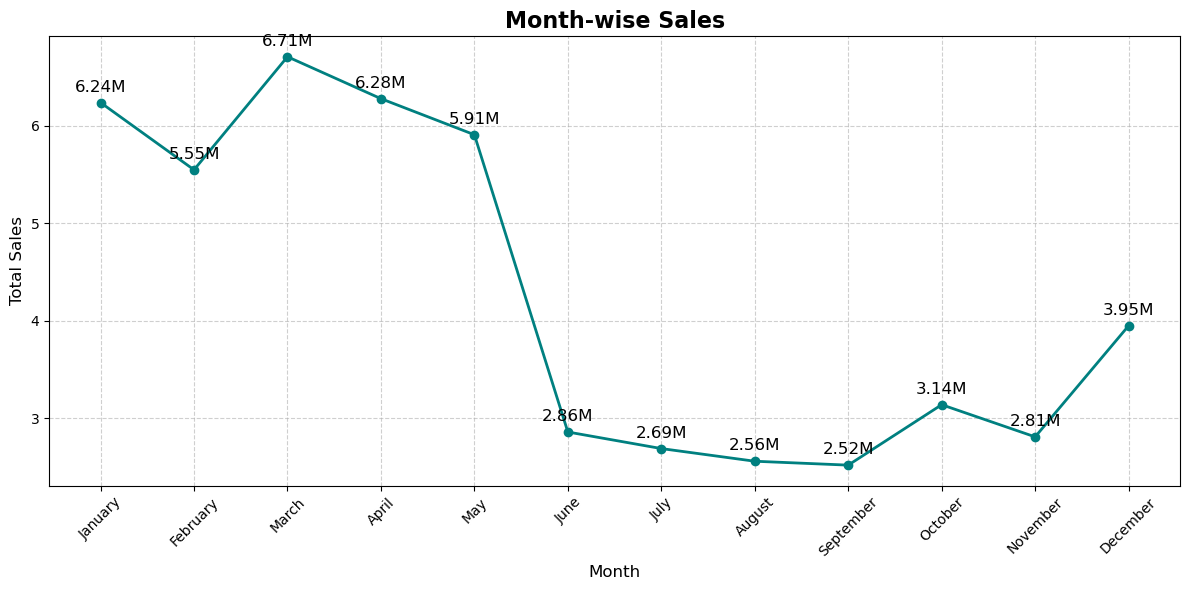

In [67]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2, color='teal')
plt.title('Month-wise Sales', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

for i, v in enumerate(monthly_sales.values):
    plt.text(i, v + 0.08, f'{v:,.2f}M', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

#### 4) Show City wise sales

#### a) Replace City Names

In [69]:
df['City'] = df['City'].map(city_mapping)

print(df['City'].value_counts())

City
Lahore        155
Quetta         97
Islamabad      77
Peshawar       71
Faisalabad     52
Karachi        48
Name: count, dtype: int64


#### b) Horizontal Bar Chart using Seaborn

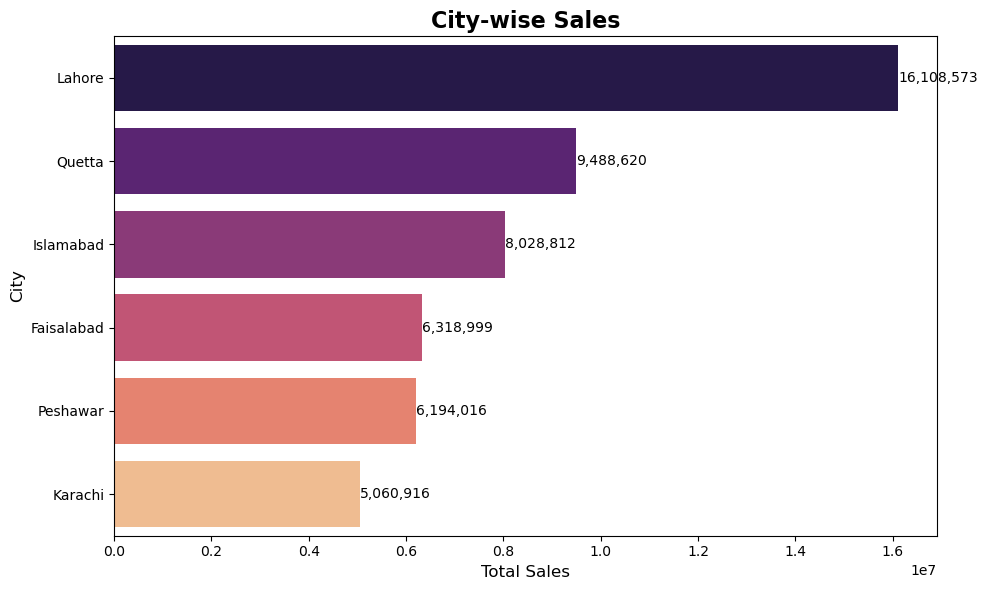

In [70]:
city_sales = df.groupby('City')['total'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=city_sales.values, y=city_sales.index, palette='magma')
plt.title('City-wise Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('City', fontsize=12)

for i, v in enumerate(city_sales.values):
    plt.text(v, i, f'{v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

#### c) Write Observation

#### 5) Show monthly Sales by Category

#### a) Side by side bar chart using matplotlib

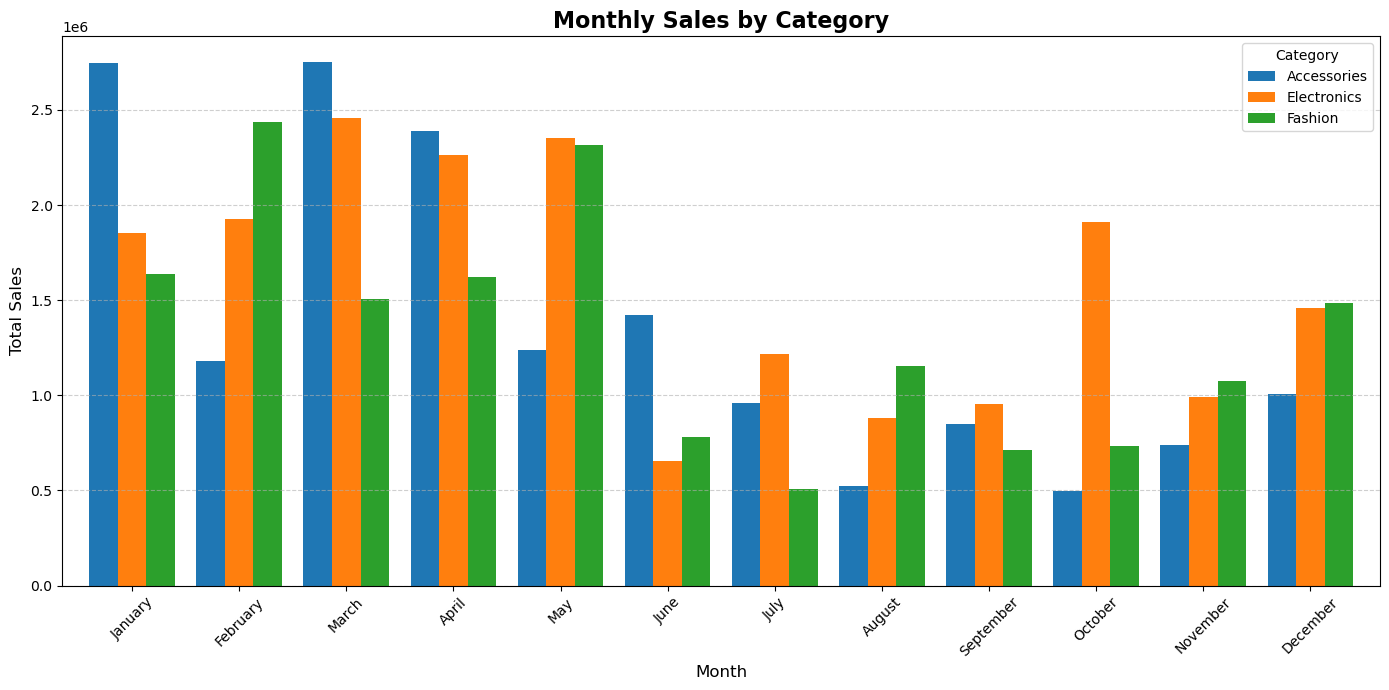

In [71]:
monthly_category_sales = df.pivot_table(index='Month', columns='category', 
                                        values='total', aggfunc='sum').reindex(month_order)

monthly_category_sales.plot(kind='bar', figsize=(14, 7), width=0.8)
plt.title('Monthly Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### b) Write Observation